In [1]:
from singleCAM_IROS._pipeline_support import _handle_dirpaths, PipelineParams

from typing import Any, NamedTuple
from pathlib import Path
import yaml

import numpy as np
from numpy.typing import NDArray
import pandas as pd
from bisect import bisect_left, bisect_right

from bloodmoon.io import simulation_files
from bloodmoon.coords import shift2angle, equatorial2shift
from bloodmoon.mask import CodedMaskCamera, codedmask
from bloodmoon.mask import count, decode
from bloodmoon.mask import variance, snratio
from bloodmoon.optim import model_shadowgram

import darksun as ds
from darksun.types import Tag
from darksun.data import Log, DataLoader, CatalogueLoader
from darksun.utils import savefig_to

In [2]:
MASK_FITS: str = "wfm_mask_NTHT_20250725.fits"

SKYFIELD: str = "GalacticCentre"
DATA_FITS: str = "galctr_rxte-sax_2-50keV_mask_050_1040x17_opaquemask_infdet"

ANALYSIS_ID: str = "singleCAM_iros_upx2upy1_newOptimiser_smoothing"

ID_CAMERA_A: str = "cam1a"
ID_CAMERA_B: str = "cam1b"
DATASET: str = "reconstructed"

UPS_X: int = 2
UPS_Y: int = 1

VIGNETTING: bool = True
PSFY: bool = (
    True if DATASET == 'reconstructed'
    else False
)

In [3]:
# load filepaths
mask_path, simul_data, save_path = _handle_dirpaths(
    mask=MASK_FITS,
    skyfield=SKYFIELD,
    simul=DATA_FITS,
    run_name=ANALYSIS_ID,
)
wfm: CodedMaskCamera = codedmask(mask_path, UPS_X, UPS_Y)
filepaths: dict[str, dict[str, Path]] = simulation_files(simul_data)

# data from camera A
sdlA = ds.get_data(filepaths[ID_CAMERA_A][DATASET])
catalogueA = ds.get_catalogue(filepaths[ID_CAMERA_A]['sources'])
# data from camera B
sdlB = ds.get_data(filepaths[ID_CAMERA_B][DATASET])
catalogueB = ds.get_catalogue(filepaths[ID_CAMERA_B]['sources'])

# IROS run data logs
log_camA, log_camB = ds.load_database(save_path + f"IROS_sources_database_TEST_{ANALYSIS_ID}.fits")

# Loading data...
# Loading completed!


In [ ]:
from astropy.io.fits.fitsrec import FITS_rec

def source_catalogue_data(
    sourceID: str,
    data: FITS_rec,
) -> FITS_rec:
    """
    Extracts the source data from the catalogue.
    """
    return np.unique(data[(data['ID'] == sourceID)])[0]


def save_region_file(
    log: Log,
    catalogue: CatalogueLoader,
    save_to: str | Path,
) -> None:
    """
    Saves a `.reg` (region) file with info about the reconstructed
    IROS sources, i.e., their respective RA/Dec coordinates from
    the catalogue in the `fk5` reference frame.

    Args:
        log (Log):
            IROS reconstructed sources database.
        catalogue (CatalogueLoader):
            Catalogue data for the LEM-X coded-mask camera.
        save_to (str | Path):
            Path for where to save the `.reg` file.
    """
    SETUP = {
        'format': 'DS9 version 4.1',
        'refsystem': 'fk5',
        'circles_size': 400.0,

        'options': {
            'color': 'green',
            'dashlist': '8 3',
            'width': 1,
            'font': '"helvetica 10 normal roman"',
            'select': 1,
            'highlite': 1,
            'dash': 0,
            'fixed': 0,
            'edit': 1,
            'move': 1,
            'delete': 1,
            'include': 1,
            'source': 1,
        },
    }

    # populate list with sources location
    source_list = []
    for sourceID in log.log['ID']:
        source_data = source_catalogue_data(sourceID, catalogue.DLdata)
        source_list.append(
            (sourceID, source_data['RA'], source_data['DEC'])
        )
    
    # write .reg file with custom options
    global_options = [
        f'{key}={value} ' for key, value in SETUP['options'].items()
    ]
    tags = [
        f'circle({ra}, {dec}, {SETUP['circles_size']}{'"'}) # text={{{sID}}}\n'
        for (sID, ra, dec) in source_list
    ]
    with open(save_to, "w", encoding="utf-8") as f:
        f.write(f'# Region file format: {SETUP['format']}\n')
        f.write('global ')
        f.writelines(global_options)
        f.write('\n')
        f.write(f'{SETUP['refsystem']}\n')
        f.writelines(tags)

    return None


def save_pipeline_params(
    params: PipelineParams,
    save_to: str | Path,
) -> None:
    """
    Saves a `.yaml` file with info about the IROS pipeline, indicating all
    the useful parameters for replicating the reconstruction procedure.

    Args:
        params (PipelineParams):
            PipelineParams instance with the initialized parameters for the pipeline.
        save_to (str | Path):
            Path for where to save the `.yaml` file.
    """
    dict_ = params.__dict__
    to_yaml = yaml.dump(dict_, indent=4, sort_keys=False)

    _init_comment = (
        f'#### OUTPUT FILE FOR IROS RECONSTRUCTION \n'
        f'# This file serves as a container for all the parameters/info to replicate the IROS run.\n'
        f'\n'
        f'# ARGS:\n'
        f'#     - `mask_file`, `simul_data` and `save_path` are the paths to the mask and data files;\n'
        f'#     - `vignetting` and `psfy` represent the active instrumental effects;\n'
        f'#     - `module_cameras` contains the ID for the two coded-mask cameras of the LEM-X module;\n'
        f'#     - `dataset` is the photons reconstruction logic-type of the data;\n'
        f'#     - `start_ups` and `final_ups` are the starting and final images upsampling factors in the (fine, coarse) directions;\n'
        f'#     - `iros_max_iterations` is the max number of IROS iterations;\n'
        f'#     - `iros_snr_threshold` is the significance threshold for the candidates validation;\n'
        f'#     - `sky_compositions` is a flag for the cameras sky images composition;\n'
        f'#     - `simul_names`, ..., `out_comp_name` are the names with which the pipeline files are saved;\n'
        f'#     - `E_min` and `E_max` are the limits on the data energy range (in keV);\n'
        f'#     - `coords` contains the sources RA/Dec coords that have been filtered out from the analysis (filtered out photons);\n'
        f'#     - `F_min` and `F_max` are the limits on the catalogue sources flux range for the candidates comparison (in ph/cm2/s);\n'
        f'#     - `IROSrun_region_file_CamA` and `IROSrun_region_file_CamB` are the names of the `.reg` files with the IROS reconstructed sources;\n'
        f'\n\n'
    )
    _end_comment = (
        f'\n\n'
        f'# end'
    )

    with open(save_to, "w", encoding="utf-8") as f:
        f.write(_init_comment)
        f.write(to_yaml)
        f.write(_end_comment)
    
    return None

<br>

## **Funcs to insert in Darksun**

In [7]:
assert False

AssertionError: 

In [ ]:
from typing import Any, NamedTuple, Sequence
from bisect import bisect_left, bisect_right
from pathlib import Path

import numpy as np
from numpy.typing import NDArray
from pandas import DataFrame
from astropy.io.fits.fitsrec import FITS_rec

from bloodmoon.types import CoordEquatorial
from bloodmoon.coords import equatorial2shift, shift2angle
from bloodmoon.mask import CodedMaskCamera
from bloodmoon.mask import count
from bloodmoon.optim import model_shadowgram, model_sky

from darksun.data import Log, CatalogueLoader, DataLoader
from darksun.images import crop, upscale
from darksun.optim import bkg_smoothing
from darksun.show import map4image, image_plot, slices_plot
from darksun.utils import savefig_to

In [ ]:
# Objects

class Candidate(NamedTuple):
    """
    Source candidate main info container.

    Attributes:
        shift_x (float):
            Coded-mask camera local frame sky-coord along the x-axis [mm].
        shift_y (float):
            Coded-mask camera local frame sky-coord along the y-axis [mm].
        fluence (float):
            Observed candidate fluence [ph].
        snr (float):
            Candidate significance [adim].
    """
    shift_x: float
    shift_y: float
    fluence: float
    snr: float

In [ ]:
# source photons filtering

def select_source_photons(
    coords: CoordEquatorial | Sequence[CoordEquatorial],
    data: FITS_rec,
    verbose: bool = True,
) -> FITS_rec:
    """
    Selects photon events relative to the input source RA/Dec coords.
    """
    mask = np.ones(len(data), dtype=bool)
    coords_ = (coords,) if isinstance(coords, CoordEquatorial) else coords
    for c in coords_:
        mask &= (
            (np.isclose(data['RA'], c.ra) & np.isclose(data['DEC'], c.dec))
        )
    selected = data[mask]
    if verbose:
        print(f'Selected {len(selected)}/{len(data)} photons.')
    return selected

In [ ]:
# smoothing

def get_candidates(
    log: Log,
    thresh: int | float,
    verbose: bool = True,
) -> tuple[Candidate, ...]:
    """
    Extracts the candidates from the IROS log with a
    significance lower than the input threshold.
    """
    idx: int = np.argwhere(
        np.array(log.log['snr']) < thresh
    )[0, 0]

    candidates: tuple[Candidate, ...] = tuple(
        Candidate(sx, sy, f, signf) for sx, sy, f, signf in zip(
            log.log['shift_x'][:idx],
            log.log['shift_y'][:idx],
            log.log['fluence'][:idx],
            log.log['snr'][:idx],
        )
    )
    if verbose:
        print(
            f"Number of candidates with SNR > {thresh}: {len(candidates)}\n"
            f"Last: {log.log['ID'][idx - 1]} (snr = {log.log['snr'][idx - 1]:.2f})\n"
            f"Following: {log.log['ID'][idx]} (snr = {log.log['snr'][idx]:.2f})\n"
        )
    return candidates


def retrieve_detector(
    candidates: tuple[Candidate, ...],
    camera: CodedMaskCamera,
    vignetting: bool,
    psfy: bool,
) -> NDArray:
    """
    Generates detector image from retrieved candidates.
    """
    detector = np.zeros(camera.shape_detector)
    for (sx, sy, f, _) in candidates:
        sg = model_shadowgram(
            camera=camera,
            shift_x=sx,
            shift_y=sy,
            vignetting=vignetting,
            psfy=psfy,
        )
        detector += (f * sg)
    return detector


def detector_smoothing(
    detector: NDArray,
    candidates: tuple[Candidate, ...],
    camera: CodedMaskCamera,
    vignetting: bool,
    psfy: bool,
    kernelsize_y: int = 11,
    kernelsize_x: int = 7,
) -> NDArray:
    """
    Process the observed detector image by applying
    a median smoothing of the background.
    """
    # get residual detector image
    retrieved = retrieve_detector(
        candidates=candidates,
        camera=camera,
        vignetting=vignetting,
        psfy=psfy,
    )
    res_detector = detector - retrieved
    # perform smoothing on residual detector image
    res_smoothed = bkg_smoothing(
        detector=res_detector,
        camera=camera,
        kernelsize_y=kernelsize_y,
        kernelsize_x=kernelsize_x,
    )
    # get smoothed detector image
    smoothed = detector - res_smoothed
    return smoothed

In [ ]:
# imaging and processing

def collapse_view(arr: NDArray) -> tuple[NDArray, NDArray]:
    """
    Collapses input 2D array by adding the elements along
    one axis, for both the (x, y) array axes.

    Returns:
        output (tuple[NDArray, NDArray]):
            - collapsed array along the y axis
            - collapsed array along the x axis
    
    ## Notes:
        - if `arr.shape = (n, m)`, the collapsed array
          along y has length `m`, while the collapsed
          array along x has length `n`.
    """
    return np.sum(arr, axis=0), np.sum(arr, axis=1)


def config_distr_limits(
    bins: NDArray,
    start: int | float | None,
    stop: int | float | None,
) -> tuple[slice, slice]:
    """
    Configures histogram distribution values to show.

    Args:
        bins (NDArray): Bins array values.
        start (int | float): Inf values limit.
        stop (int | float): Sup values limit.
    
    Returns:
        output (tuple[slice, slice]):
            - slice obj for bins values
            - slice obj for histogram values
    """
    i_min = (
        bisect_right(bins, start) - 1 if start is not None else None
    )
    i_max = (
        bisect_left(bins, stop) if stop is not None else None
    )
    slice_bins = slice(i_min, i_max)
    slice_hist = slice(i_min, i_max - 1 if i_max is not None else None)
    return slice_bins, slice_hist


def pixels_angular_resolution(
    camera: CodedMaskCamera,
    verbose: bool = True,
) -> tuple[float, float]:
    """
    Returns the camera pixels angular resolution in [arcmin].
    """
    pxs = (
        camera.specs.mask_deltax / camera.upscale_f.x,
        camera.specs.mask_deltay / camera.upscale_f.y,
    )
    dtheta_x, dtheta_y = map(
        lambda x: np.rad2deg(np.arctan(x / camera.specs.mask_detector_distance)) * 60,
        pxs,
    )
    if verbose:
        print(
            f"\n"
            f"Pixel angular resolution at upscaling (x, y): ({camera.upscale_f.x}, {camera.upscale_f.y})\n"
            f"  - fine direction: {dtheta_x:.4f} arcmin\n"
            f"  - coarse direction: {dtheta_y:.4f} arcmin"
            f"\n"
        )
    return dtheta_x, dtheta_y


def psf_extension(
    camera: CodedMaskCamera,
    offset_fine: int = 1,
    offset_coarse: int = 1,
) -> tuple[int, int]:
    """
    Computes a source PSF extension in pixels.
    """
    slit_fine, slit_coarse = (
        int(camera.specs.slit_deltax * camera.upscale_f.x / camera.specs.mask_deltax) + offset_fine,
        int(camera.specs.slit_deltay * camera.upscale_f.y / camera.specs.mask_deltay) + offset_coarse,
    )
    return slit_fine, slit_coarse


def crop_source_psf(
    camera: CodedMaskCamera,
    pos: tuple[int, int],
    offset_fine: int = 1,
    offset_coarse: int = 1,
) -> tuple[slice, slice]:
    """
    Crops a source PSF with the given offset along fine and coarse directions.
    """
    crop_fine, crop_coarse = psf_extension(camera, offset_fine, offset_coarse)
    i, j = pos
    slice_rows, slice_cols = (
        slice(i - crop_coarse, i + crop_coarse + 1),
        slice(j - crop_fine, j + crop_fine + 1),
    )
    return slice_rows, slice_cols


def dict2df(data: dict[str, dict[str, Any]]) -> DataFrame:
    """
    Converts input data dict in Dataframe.
    """
    dmap = {
        (cam, param): values
        for cam, cam_data in data.items() 
        for param, values in cam_data.items()
    }
    return DataFrame(dmap)

In [ ]:
# sources data from catalogue

def source_catalogue_data(
    sourceID: str,
    data: FITS_rec,
) -> FITS_rec:
    """
    Extracts the source data from the catalogue.
    """
    return np.unique(data[(data['ID'] == sourceID)])[0]


def source_angular_coords(
    sourceID: str,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
) -> tuple[float, float]:
    """
    Extracts the source angular coords from the catalogue.
    """
    data = source_catalogue_data(sourceID, catalogue.DLdata)
    shifts = equatorial2shift(sdl, camera, data['RA'], data['DEC'])
    thetax, thetay = map(lambda x: shift2angle(camera, x), shifts)
    return thetax, thetay


def source_fluence(
    sourceID: str,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
    verbose: bool = True,
) -> float:
    """
    Extracts the true source fluence from the WISEMAN data.
    """
    data = source_catalogue_data(sourceID, catalogue.DLdata)
    coords = CoordEquatorial(data['RA'], data['DEC'])
    total_photons = select_source_photons(coords, sdl.DLdata, verbose)
    # remove photons fell in detector plane dead zone
    det_image = count(camera, total_photons)[0] * (camera.bulk > 0)
    return det_image.sum()


def extract_data_info(
    cameraID: str,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
    verbose: bool = True,
) -> DataFrame:
    """
    Extracts the sources info from the catalogue.
    """
    # compute sources camera local-frame angular coords and fluence
    sources, thetas_x, thetas_y, fluences = [], [], [], []
    for sourceID in np.unique(catalogue.DLdata['ID']):
        thx, thy = source_angular_coords(sourceID, catalogue, sdl, camera)
        fluence = source_fluence(sourceID, catalogue, sdl, camera, verbose)
        sources.append(sourceID)
        thetas_x.append(thx)
        thetas_y.append(thy)
        fluences.append(fluence)
    
    dmap = {
        cameraID: {
            'ID': sources,
            'angle_x': thetas_x,
            'angle_y': thetas_y,
            'fluence': fluences,
        },
    }
    return dict2df(dmap)

In [ ]:
def data_DF(
    log: Log,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
) -> DataFrame:
    """
    Generates a Dataframe with output data from IROS.
    """
    raise NotImplementedError

In [ ]:
# benchmarking

def reconstructed_sources_profiles(
    true_sky: NDArray,
    log: Log,
    crp: tuple[int, int],
    camera: CodedMaskCamera,
    *,
    vignetting: bool = True,
    psfy: bool = True,
    save_to: str | Path | None = None,
) -> None:
    """
    Displays the IROS reconstruction effect wrt the original decoded sky.

    Specifically, it shows:
        - IROS reconstructed source slices wrt the true sky
        - source slices residues

    Args:
        true_sky (NDArray):
            True observed decoded sky.
        log (Log):
            Reconstructed sources database.
        crp (tuple[int, int]):
            Size of the cropping along fine/coarse directions.
        camera (CodedMaskCamera):
            CodedMaskCamera instance used for imaging and reconstruction.
        vignetting (bool, optional (default=`True`)):
            Simulates vignetting effects.
        psfy (bool, optional (default=`True`)):
            Simulates detector reconstruction effects.
        save_to (str | Path | None, optional (default=`None`)):
            Path to the directory where to save the plots.
    
    ## Notes:
        - A copy of `true_sky` is used to avoid memory overwrite.
    """
    true_sky_ = true_sky.copy()
    res_ground = np.zeros_like(true_sky_)

    for source, sx, sy, f, x, y in zip(
        log.log['ID'],
        log.log['shift_x'],
        log.log['shift_y'],
        log.log['fluence'],
        log.log['x'],
        log.log['y'],
    ):
        POS = (y, x)

        # simulate source
        modeled = model_sky(
            camera=camera,
            shift_x=sx,
            shift_y=sy,
            fluence=f,
            vignetting=vignetting,
            psfy=psfy,
        ).astype(np.int32)

        # plot IROS vs True skies slices (profiles and residues)
        slices_plot(
            sky=(true_sky_, modeled),
            pos=POS,
            crp=crp,
            source=source,
            labels=('True', 'IROS'),
            cameraID=log.name,
            save_to=(
                savefig_to(save_to, f'{source.upper()}_profile_{log.name.upper()}')
                if save_to is not None else None
            ),
        )
        slices_plot(
            sky=(res_ground, true_sky_ - modeled),
            pos=POS,
            crp=crp,
            source=source,
            labels=('', 'true - IROS'),
            ylabel='residues [ph]',
            cameraID=log.name,
            save_to=(
                savefig_to(save_to, f'{source.upper()}_profile_res_{log.name.upper()}')
                if save_to is not None else None
            ),
        )

        # remove source from True sky
        true_sky_ -= modeled


def reconstruction_sources_heatmaps(
    true_sky: NDArray,
    log: Log,
    crp: tuple[int, int],
    camera: CodedMaskCamera,
    *,
    vignetting: bool = True,
    psfy: bool = True,
    save_to: str | Path | None = None,
) -> None:
    """
    Displays the IROS reconstruction effect wrt the original decoded sky.
    Specifically, it shows the heatmaps residues between the ground
    truth and the IROS reconstructed sources in the input `log`.

    Args:
        true_sky (NDArray):
            True observed decoded sky.
        log (Log):
            Reconstructed sources database.
        crp (tuple[int, int]):
            Size of the cropping along sky image (rows, cols).
        camera (CodedMaskCamera):
            CodedMaskCamera instance used for imaging and reconstruction.
        vignetting (bool, optional (default=`True`)):
            Simulates vignetting effects.
        psfy (bool, optional (default=`True`)):
            Simulates detector reconstruction effects.
        save_to (str | Path | None, optional (default=`None`)):
            Path to the directory where to save the plots.
    
    ## Notes:
        - A copy of `true_sky` is used to avoid memory overwrite.
    """
    true_sky_ = true_sky.copy()

    for source, sx, sy, f, x, y in zip(
        log.log['ID'],
        log.log['shift_x'],
        log.log['shift_y'],
        log.log['fluence'],
        log.log['x'],
        log.log['y'],
    ):
        POS = (y, x)

        # simulate source
        modeled = model_sky(
            camera=camera,
            shift_x=sx,
            shift_y=sy,
            fluence=f,
            vignetting=vignetting,
            psfy=psfy,
        ).astype(np.int32)

        # plot IROS vs True residues heatmaps
        F_UPY, F_UPX = 2, 5

        true_crp, modeled_crp = map(
            lambda x: crop(x, pos=POS, crp=crp, strict=False),
            (true_sky_, modeled),
        )
        vlim = np.max(np.abs(true_crp - modeled_crp))
        image_plot(
            dmaps=map4image(
                img=upscale(true_crp - modeled_crp, F_UPY, F_UPX) * np.prod((F_UPY, F_UPX)),
                title=f'{source.upper()} True - IROS Residues {log.name}',
                cbarlabel='residues [ph]',
                img_kwargs={
                    'vmin': -vlim,
                    'vmax': vlim,
                    'cmap': 'bwr',
                    'extent': (-crp[1] * F_UPX, crp[1] * F_UPX, -crp[0] * F_UPY, crp[0] * F_UPY),
                },
            ),
            save_to=(
                savefig_to(save_to, f'{source.upper()}_resHM_{log.name.upper()}')
                if save_to is not None else None
            ),
        )

        # remove source from True sky
        true_sky_ -= modeled

<br>

<br>

## **WISEMAN camera orientation**

In [ ]:
assert False

CAM1H
  Crab Source Position in the camera local-frame coords
  - shifts: (-52.55320588166768, -56.199841769251)
  - angles: (np.float64(-14.510818374736035), np.float64(-15.470935671066176))
  - RA - DEC: CoordEquatorial(ra=83.6332015991211, dec=22.014499664306626)
  - CAM pointings: {'z': CoordEquatorial(ra=65.6737015953277, dec=35.6486362123488), 'x': CoordEquatorial(ra=257.33165649948, dec=53.7838910823791)}
  - Wanted CAM pointings: CoordEquatorial(ra=83.1078519664901, dec=21.540083357047777)



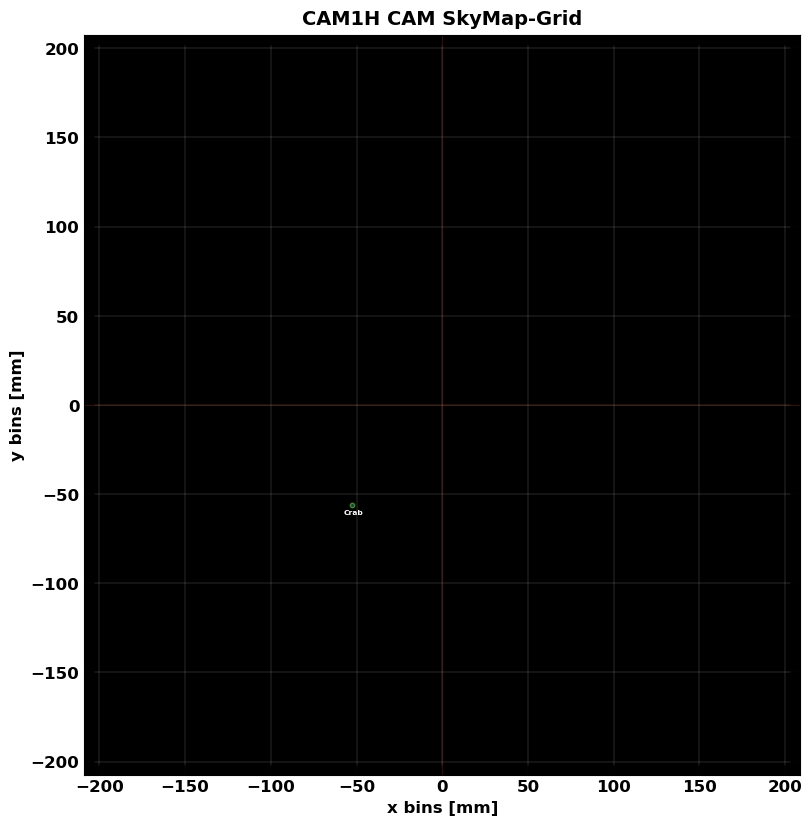

In [ ]:
from pathlib import Path

from bloodmoon.coords import equatorial2shift, shift2angle, shift2equatorial, angle2shift
from bloodmoon.mask import codedmask, count, decode

import darksun as ds
from darksun.types import LogEntry
from darksun.show import skyfield_map


# setup mask and data
base_path = '/home/edoardo/Datadisk/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Simulations'
skyfield = 'Crab/PointingTests'
mask_FITS = 'wfm_mask_NTHT_20250725.fits'
data_FITS = 'test_camera_tilt'
filepath = f'{base_path}/{skyfield}/{data_FITS}'

UPX, UPY = 1, 1
wfm = codedmask(f'{base_path}/{mask_FITS}', UPX, UPY)

CrabRA = 83.6332015991211
CrabDEC = 22.0144996643066
cameras = tuple(p.name for p in Path(filepath).glob('*cam1h*') if p.is_dir())


for camID in cameras:
    sdlA = ds.get_data(f'{filepath}/{camID}/{data_FITS}_{camID}_detected.fits')
    detector, _ = count(wfm, sdlA.DLdata)
    sky = decode(wfm, detector)
    shiftx, shifty = equatorial2shift(sdlA, wfm, CrabRA, CrabDEC)
    thetax, thetay = tuple(map(lambda x: shift2angle(wfm, x), (shiftx, shifty)))
    print(
        f'{camID.upper()}\n'
        f'  Crab Source Position in the camera local-frame coords\n'
        f'  - shifts: {shiftx, shifty}\n'
        f'  - angles: {thetax, thetay}\n'
        f'  - RA - DEC: {shift2equatorial(sdlA, wfm, shiftx, shifty)}\n'
        f'  - CAM pointings: {sdlA.pointings}\n'
        f'  - Wanted CAM pointings: {shift2equatorial(
            sdlA, wfm, angle2shift(wfm, -15.0), angle2shift(wfm, -15.0),
        )}\n'
    )

    # show source position in skymap
    params = (
        LogEntry('ID', '20A', ''), LogEntry('shift_x', 'D', 'mm'), LogEntry('shift_y', 'D', 'mm'),
    )
    source_log = ds.create_log(
        params=params,
        name=f'{camID} CAM'
    )
    source_log.update(tuple((p.entry, val) for p, val in zip(params, ('Crab', shiftx, shifty))))
    skyfield_map(
        log=source_log,
        camera=wfm,
    )